<h2 style='color:blue' align="center">Logistic Regression: Multiclass Classification</h2>

In this tutorial we will see how to use logistic regression for multiclass classification.

https://scikit-learn.org/1.5/auto_examples/datasets/plot_digits_last_image.html

In [ ]:
from sklearn.datasets import load_digits
%matplotlib inline
import matplotlib.pyplot as plt
digits = load_digits()

In [ ]:
dir(digits)

['DESCR', 'data', 'images', 'target', 'target_names']

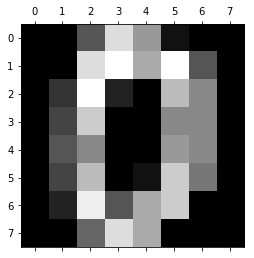

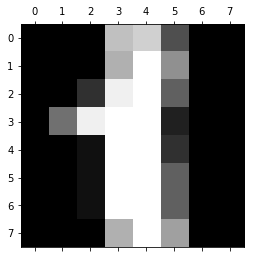

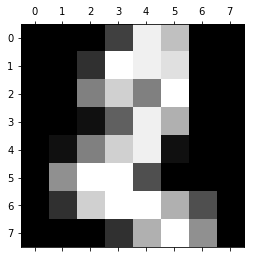

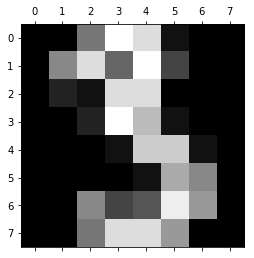

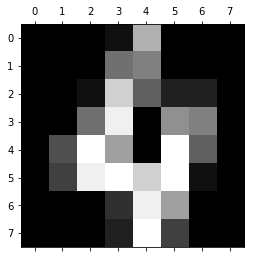

In [ ]:
plt.gray()
for i in range(5):
    plt.matshow(digits.images[i])

In [ ]:
digits.data[0] #8 X 8 array -> 64

array([  0.,   0.,   5.,  13.,   9.,   1.,   0.,   0.,   0.,   0.,  13.,
        15.,  10.,  15.,   5.,   0.,   0.,   3.,  15.,   2.,   0.,  11.,
         8.,   0.,   0.,   4.,  12.,   0.,   0.,   8.,   8.,   0.,   0.,
         5.,   8.,   0.,   0.,   9.,   8.,   0.,   0.,   4.,  11.,   0.,
         1.,  12.,   7.,   0.,   0.,   2.,  14.,   5.,  10.,  12.,   0.,
         0.,   0.,   0.,   6.,  13.,  10.,   0.,   0.,   0.])

<h4 style='color:purple'>Create and train logistic regression model</h4>

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(digits.data,digits.target, test_size=0.2)

In [ ]:
len(X_train)

In [ ]:
len(x_test)

In [ ]:
model.fit(X_train, y_train) #x_train have image sample and y_train has text sample

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

<h4 style='color:purple'>Measure accuracy of our model</h4>

In [ ]:
model.score(X_test, y_test)

0.93333333333333335

In [ ]:
model.predict(digits.data[0:5])

array([0, 1, 2, 3, 4])

<h4 style='color:purple'>Confusion Matrix</h4>

In [ ]:
y_predicted = model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
cm

array([[31,  0,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 0, 47,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 0,  0, 34,  1,  0,  0,  0,  0,  1,  0],
       [ 0,  0,  0, 35,  0,  0,  0,  1,  4,  2],
       [ 0,  2,  0,  0, 29,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  0, 32,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 41,  0,  1,  0],
       [ 0,  0,  0,  1,  0,  0,  0, 32,  0,  1],
       [ 0,  4,  0,  0,  0,  0,  0,  0, 29,  0],
       [ 0,  0,  0,  1,  1,  0,  0,  0,  0, 26]], dtype=int64)

Text(69,0.5,'Truth')

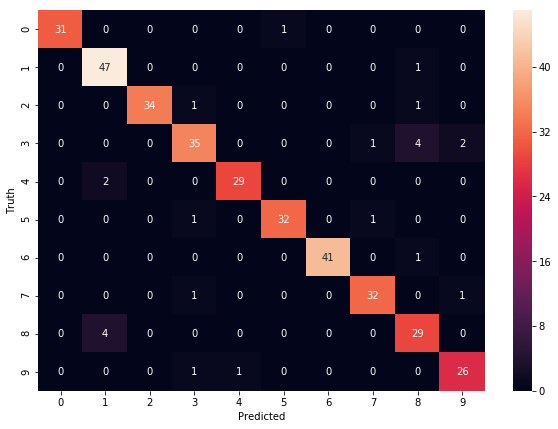

In [ ]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

**Exercise**

Use sklearn.datasets iris flower dataset to train your model using logistic regression. You need to figure out accuracy
of your model and use that to predict different samples in your test dataset. In iris dataset there are 150 samples containing following features,

1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

Using above 4 features you will clasify a flower in one of the three categories,

1. Setosa
2. Versicolour
3. Virginica

https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html

In [1]:
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [5]:
# Load the data by iris
iris = load_iris()

In [6]:
print("Data Shape (Rows, Columns):", iris.data.shape)

Data Shape (Rows, Columns): (150, 4)


In [10]:
print("Feature Names:", iris.feature_names)

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [11]:
print("\nFirst 5 rows of data (Features):")
print(iris.data[:5])


First 5 rows of data (Features):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [12]:
# 2. Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)


In [13]:
# 3. Create and train the Logistic Regression model
# max_iter is set to 200 to ensure the solver converges fully on this dataset
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [14]:
# 4. Measure the accuracy of the model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

Model Accuracy: 100.00%



In [15]:
# 5. Predict different samples in your test dataset
y_predicted = model.predict(X_test)

# Print the first 5 predictions vs actual targets to see it in action
print("First 5 Test Sample Predictions (Numeric):", y_predicted[:5])
print("First 5 Test Sample Actual Truth (Numeric):", y_test[:5])

# Map numbers back to actual flower names for clarity
predicted_names = [iris.target_names[i] for i in y_predicted[:5]]
actual_names = [iris.target_names[i] for i in y_test[:5]]
print("Predicted Names:", predicted_names)
print("Actual Names:   ", actual_names, "\n")

First 5 Test Sample Predictions (Numeric): [1 0 2 1 1]
First 5 Test Sample Actual Truth (Numeric): [1 0 2 1 1]
Predicted Names: [np.str_('versicolor'), np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor')]
Actual Names:    [np.str_('versicolor'), np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor')] 



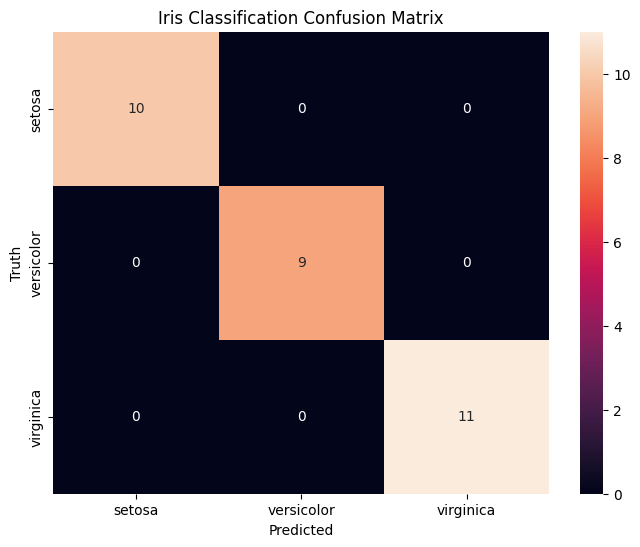

In [16]:
# 6. Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test, y_predicted)

plt.figure(figsize=(8, 6))
sn.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
)
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Iris Classification Confusion Matrix")
plt.show()